<div style="background:#1a1a2e; padding:30px; border-radius:10px; text-align:center;">
  <h1 style="color:white; font-size:28px; margin:0;">
    AnalystLab Africa — Week 1 & Week 2
  </h1>
  <p style="color:#aaa; margin:8px 0 0;">
    Data Cleaning & Exploratory Data Analysis
  </p>
    <p style="color:#aaa; margin:8px 0 0;">
    E-COMMERCE DATASET
  </p>
  <p style="color:#888; font-size:20px; margin:6px 0 0;">
     June 2026  |  Lindsly Muyonda
  </p>
</div>

In [ ]:
pip install pandas numpy matplotlib seaborn openpyxl 

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)


------
## Section1: E-Commerce Dataset
> **Source:** UCI Online Retail Dataset — Kaggle

> This dataset contains transactional records from a UK-based online retail store covering the period between December 2010 and December 2011. Each row represents one line item in a customer invoice, recording details such as the product purchased, quantity, unit price, customer ID and the country of the transaction
-------

## Task 1: Dataset Understanding

In [61]:
df_ec = pd.read_csv(r'C:\Users\hp\Downloads\OnlineRetail.csv', encoding='ISO-8859-1')
print("Loaded successfully!")
print(df_ec.shape)


Loaded successfully!
(541909, 8)


In [62]:
print("=== E-COMMERCE DATASET ===")
print("\nFirst 5 rows:")
display(df_ec.head())

print("\nShape (rows, columns):", df_ec.shape)
print("\nColumn names:", df_ec.columns.tolist())

=== E-COMMERCE DATASET ===

First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.00,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.00,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.00,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.00,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.00,United Kingdom



Shape (rows, columns): (541909, 8)

Column names: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [59]:
print("\nData types:")
print(df_ec.dtypes)

print("\nBasic info:")
df_ec.info()


Data types:
invoiceno              object
stockcode              object
description            object
quantity                int64
invoicedate    datetime64[ns]
unitprice             float64
customerid             object
country                object
revenue               float64
year_month          period[M]
price_range          category
dtype: object

Basic info:
<class 'pandas.core.frame.DataFrame'>
Index: 524878 entries, 0 to 541908
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   invoiceno    524878 non-null  object        
 1   stockcode    524878 non-null  object        
 2   description  524878 non-null  object        
 3   quantity     524878 non-null  int64         
 4   invoicedate  524878 non-null  datetime64[ns]
 5   unitprice    524878 non-null  float64       
 6   customerid   524878 non-null  object        
 7   country      524878 non-null  object        
 8   revenue      524878

In [63]:
# Numerical features
num_cols_ec = df_ec.select_dtypes(include=['number']).columns.tolist()
print("Numerical columns:", num_cols_ec)

# Categorical features
cat_cols_ec = df_ec.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns:", cat_cols_ec)

# Unique identifiers / possible primary keys
print("\nUnique InvoiceNo count:", df_ec['InvoiceNo'].nunique())
print("Total rows:", len(df_ec))
print("Possible PK: InvoiceNo + StockCode (composite key)")

Numerical columns: ['Quantity', 'UnitPrice', 'CustomerID']
Categorical columns: ['InvoiceNo', 'StockCode', 'Description', 'InvoiceDate', 'Country']

Unique InvoiceNo count: 25900
Total rows: 541909
Possible PK: InvoiceNo + StockCode (composite key)


## Task 2: Data Cleaning

> In this task we will systematically identify and fix all these issues, documenting every action taken and the reason behind each decision.

#### Missing Values
We first identify columns with missing values and count them.
Strategy:
CustomerID: Filled with "Unknown" to retain valid transaction records.
Description: Filled with "No Description" to preserve rows with missing product names.

In [31]:
print("=== MISSING VALUES — E-COMMERCE ===")
missing_ec = df_ec.isnull().sum()
missing_pct_ec = (df_ec.isnull().sum() / len(df_ec) * 100).round(2)
missing_df_ec = pd.DataFrame({
    'Missing Count': missing_ec,
    'Missing %': missing_pct_ec
}).query('`Missing Count` > 0')
print(missing_df_ec)

# CustomerID: many missing — these are guest/anonymous purchases → keep rows but fill with 'Unknown'
df_ec['CustomerID'] = df_ec['CustomerID'].fillna('Unknown')

# Description: few missing → fill with 'No Description'
df_ec['Description'] = df_ec['Description'].fillna('No Description')

print("\nMissing values after cleaning:")
print(df_ec.isnull().sum().sum(), "remaining")

=== MISSING VALUES — E-COMMERCE ===
             Missing Count  Missing %
Description           1454       0.27
CustomerID          135080      24.93

Missing values after cleaning:
0 remaining


In [64]:
print("=== DUPLICATES — E-COMMERCE ===")
dups_ec = df_ec.duplicated().sum()
print(f"Duplicate rows found: {dups_ec}")

df_ec = df_ec.drop_duplicates()
print(f"Rows after removing duplicates: {len(df_ec)}")

=== DUPLICATES — E-COMMERCE ===
Duplicate rows found: 5268
Rows after removing duplicates: 536641


#### Standardisation

Inconsistent formatting makes analysis difficult and unreliable. We standardise the following:
- **Column names** — renamed to lowercase with underscores for consistency
- **InvoiceDate** — converted from string to proper datetime format so we can extract months, years, and trends
- **Description** — stripped of extra spaces and converted to uppercase
- **Country** — stripped of extra spaces and converted to title case

In [65]:
print("=== STANDARDISATION — E-COMMERCE ===")

# 1. Standardise column names (lowercase, underscores)
df_ec.columns = df_ec.columns.str.strip().str.lower().str.replace(' ', '_')
print("Columns renamed:", df_ec.columns.tolist())

# 2. Parse InvoiceDate to datetime
df_ec['invoicedate'] = pd.to_datetime(df_ec['invoicedate'], errors='coerce')
print("InvoiceDate dtype:", df_ec['invoicedate'].dtype)

# 3. Standardise Description text
df_ec['description'] = df_ec['description'].str.strip().str.upper()

# 4. Standardise Country text
df_ec['country'] = df_ec['country'].str.strip().str.title()
print("Sample countries:", df_ec['country'].unique()[:5])

=== STANDARDISATION — E-COMMERCE ===
Columns renamed: ['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate', 'unitprice', 'customerid', 'country']
InvoiceDate dtype: datetime64[ns]
Sample countries: ['United Kingdom' 'France' 'Australia' 'Netherlands' 'Germany']


####  Data Validation
We check for invalid records and correct them before analysis.
Strategy:
Cancelled orders: Removed invoices starting with 'C'.
Invalid quantities: Removed rows with quantity less than or equal to zero.
Invalid prices: Removed rows with unit price less than or equal to zero.
Revenue: Created a new Revenue column (Quantity × UnitPrice).

In [66]:
print("=== VALIDATION — E-COMMERCE ===")

# Remove cancelled orders (InvoiceNo starting with 'C')
cancelled = df_ec['invoiceno'].astype(str).str.startswith('C')
print(f"Cancelled invoices found: {cancelled.sum()}")
df_ec = df_ec[~cancelled]

# Remove rows with Quantity <= 0
invalid_qty = (df_ec['quantity'] <= 0).sum()
print(f"Rows with Quantity <= 0: {invalid_qty}")
df_ec = df_ec[df_ec['quantity'] > 0]

# Remove rows with UnitPrice <= 0
invalid_price = (df_ec['unitprice'] <= 0).sum()
print(f"Rows with UnitPrice <= 0: {invalid_price}")
df_ec = df_ec[df_ec['unitprice'] > 0]

# Create revenue column
df_ec['revenue'] = df_ec['quantity'] * df_ec['unitprice']

print(f"\nClean dataset shape: {df_ec.shape}")

=== VALIDATION — E-COMMERCE ===
Cancelled invoices found: 9251
Rows with Quantity <= 0: 1336
Rows with UnitPrice <= 0: 1176

Clean dataset shape: (524878, 9)


#### Cleaning Summary

The table below summarises every cleaning action taken on the E-Commerce dataset, the issue that was found, and the method used to resolve it.

In [67]:
cleaning_summary_ec = pd.DataFrame({
    'Issue Found': [
        'Missing CustomerID',
        'Missing Description',
        'Duplicate rows',
        'Cancelled orders (InvoiceNo starts with C)',
        'Quantity <= 0',
        'UnitPrice <= 0',
        'Column names inconsistent',
        'InvoiceDate as string',
        'Text case inconsistency'
    ],
    'Action Taken': [
        'Filled with "Unknown"',
        'Filled with "No Description"',
        'Removed duplicates',
        'Removed cancelled orders',
        'Removed invalid rows',
        'Removed invalid rows',
        'Renamed to lowercase with underscores',
        'Converted to datetime',
        'Stripped & standardised to UPPER/Title case'
    ]
})
print(cleaning_summary_ec.to_string(index=False))


                               Issue Found                                Action Taken
                        Missing CustomerID                       Filled with "Unknown"
                       Missing Description                Filled with "No Description"
                            Duplicate rows                          Removed duplicates
Cancelled orders (InvoiceNo starts with C)                    Removed cancelled orders
                             Quantity <= 0                        Removed invalid rows
                            UnitPrice <= 0                        Removed invalid rows
                 Column names inconsistent       Renamed to lowercase with underscores
                     InvoiceDate as string                       Converted to datetime
                   Text case inconsistency Stripped & standardised to UPPER/Title case


##  Task 3: Exploratory Data Analysis (EDA)

> With the data now cleaned, we move into exploratory analysis. The goal is to uncover patterns, trends, and relationships hidden in the data. We start with summary statistics to understand the distribution of numerical columns, then perform five targeted analyses to answer key business questions.

In [68]:
print("=== SUMMARY STATISTICS — E-COMMERCE ===")
print(df_ec[['quantity', 'unitprice', 'revenue']].describe())

=== SUMMARY STATISTICS — E-COMMERCE ===
       quantity  unitprice   revenue
count 524878.00  524878.00 524878.00
mean      10.62       3.92     20.28
std      156.28      36.09    271.69
min        1.00       0.00      0.00
25%        1.00       1.25      3.90
50%        4.00       2.08      9.92
75%       11.00       4.13     17.70
max    80995.00   13541.33 168469.60


#### Observations from Summary Statistics

- The average quantity per transaction is relatively low, suggesting most purchases are small orders
- Unit prices vary widely — there are very cheap items and some high-value products
- Revenue is right-skewed, meaning most transactions are low value but a few are very large
- These patterns suggest the business operates on a high-volume, low-margin model

## Task 4: Data Visualizations



In [69]:
top_products = (
    df_ec.groupby('description')['quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
    .rename(columns={'quantity': 'total_quantity'})
)
print(top_products)

                          description  total_quantity
0         PAPER CRAFT , LITTLE BIRDIE           80995
1      MEDIUM CERAMIC TOP STORAGE JAR           78033
2   WORLD WAR 2 GLIDERS ASSTD DESIGNS           54951
3             JUMBO BAG RED RETROSPOT           48371
4  WHITE HANGING HEART T-LIGHT HOLDER           37872
5                      POPCORN HOLDER           36749
6     PACK OF 72 RETROSPOT CAKE CASES           36396
7       ASSORTED COLOUR BIRD ORNAMENT           36362
8                  RABBIT NIGHT LIGHT           30739
9              MINI PAINT SET VINTAGE           26633


**Finding:** The top-selling products are mostly small decorative and gift items such as the White Hanging Heart T-Light Holder. This confirms the business specialises in low-cost, high-volume novelty and gift products.

In [70]:
top_countries = (
    df_ec.groupby('country')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
print(top_countries)

          country    revenue
0  United Kingdom 9001744.09
1     Netherlands  285446.34
2            Eire  283140.52
3         Germany  228678.40
4          France  209625.37
5       Australia  138453.81
6           Spain   61558.56
7     Switzerland   57067.60
8         Belgium   41196.34
9          Sweden   38367.83


**Finding:** The United Kingdom generates significantly more revenue than any other country, which is expected for a UK-based retailer. However, countries like Germany, France and the Netherlands represent meaningful international revenue streams worth developing further.

In [71]:
df_ec['year_month'] = df_ec['invoicedate'].dt.to_period('M')
monthly_sales = (
    df_ec.groupby('year_month')['revenue']
    .sum()
    .reset_index()
)
monthly_sales['year_month'] = monthly_sales['year_month'].astype(str)
print(monthly_sales)

   year_month    revenue
0     2010-12  821452.73
1     2011-01  689811.61
2     2011-02  522545.56
3     2011-03  716215.26
4     2011-04  536968.49
5     2011-05  769296.61
6     2011-06  760547.01
7     2011-07  718076.12
8     2011-08  757841.38
9     2011-09 1056435.19
10    2011-10 1151263.73
11    2011-11 1503866.78
12    2011-12  637790.33


**Finding:** Revenue rises sharply towards the end of the year, peaking in November. This is consistent with pre-Christmas shopping and Black Friday demand. The business should ensure sufficient stock and logistics capacity heading into Q4 each year.

In [72]:
customer_stats = (
    df_ec[df_ec['customerid'] != 'Unknown']
    .groupby('customerid')
    .agg(
        total_orders=('invoiceno', 'nunique'),
        total_revenue=('revenue', 'sum'),
        avg_order_value=('revenue', 'mean')
    )
    .sort_values('total_revenue', ascending=False)
)
print("Top 10 customers by revenue:")
print(customer_stats.head(10))

Top 10 customers by revenue:
            total_orders  total_revenue  avg_order_value
customerid                                              
14646.00              73      280206.02           134.97
18102.00              60      259657.30           602.45
17450.00              46      194390.79           578.54
16446.00               2      168472.50         56157.50
14911.00             201      143711.17            25.35
12415.00              21      124914.53           174.95
14156.00              55      117210.08            84.02
17511.00              31       91062.38            94.56
16029.00              63       80850.84           335.48
12346.00               1       77183.60         77183.60


**Finding:** The distribution is heavily right-skewed — the vast majority of transactions are small in value , while a small number of transactions are worth hundreds or thousands of pounds. This means a few large orders have an outsized impact on total revenue.

In [73]:
df_ec['price_range'] = pd.cut(
    df_ec['unitprice'],
    bins=[0, 1, 5, 10, 50, 500],
    labels=['<£1', '£1–5', '£5–10', '£10–50', '>£50']
)
price_rev = df_ec.groupby('price_range')['revenue'].sum()
print(price_rev)

price_range
<£1      1104713.29
£1–5     6783774.51
£5–10    1506233.89
£10–50    857589.08
>£50      153321.12
Name: revenue, dtype: float64


**Finding:** Products priced between £1 and £5 contribute the highest total revenue despite their low individual price. This confirms the high-volume, low-price business model and suggests that maintaining a wide range of affordable products is key to the business strategy.

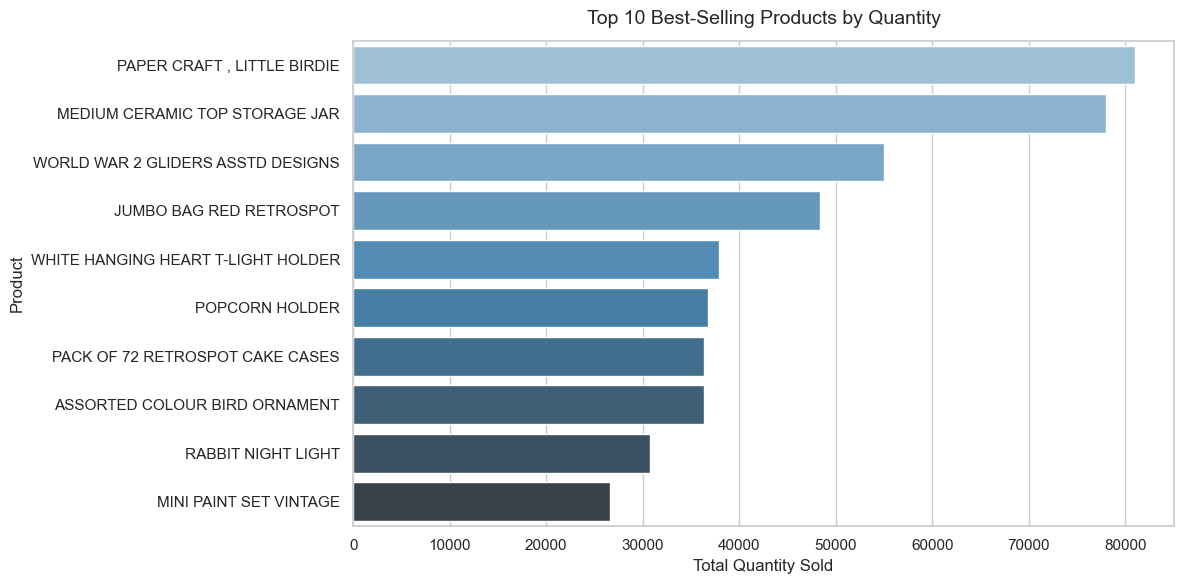

In [74]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=top_products, x='total_quantity', y='description',
            palette='Blues_d', ax=ax)
ax.set_title('Top 10 Best-Selling Products by Quantity', fontsize=14, pad=12)
ax.set_xlabel('Total Quantity Sold')
ax.set_ylabel('Product')
plt.tight_layout()
plt.savefig('ec_chart1_top_products.png', dpi=150)
plt.show()
# Finding: White Hanging Heart T-Light Holder is the most sold product.

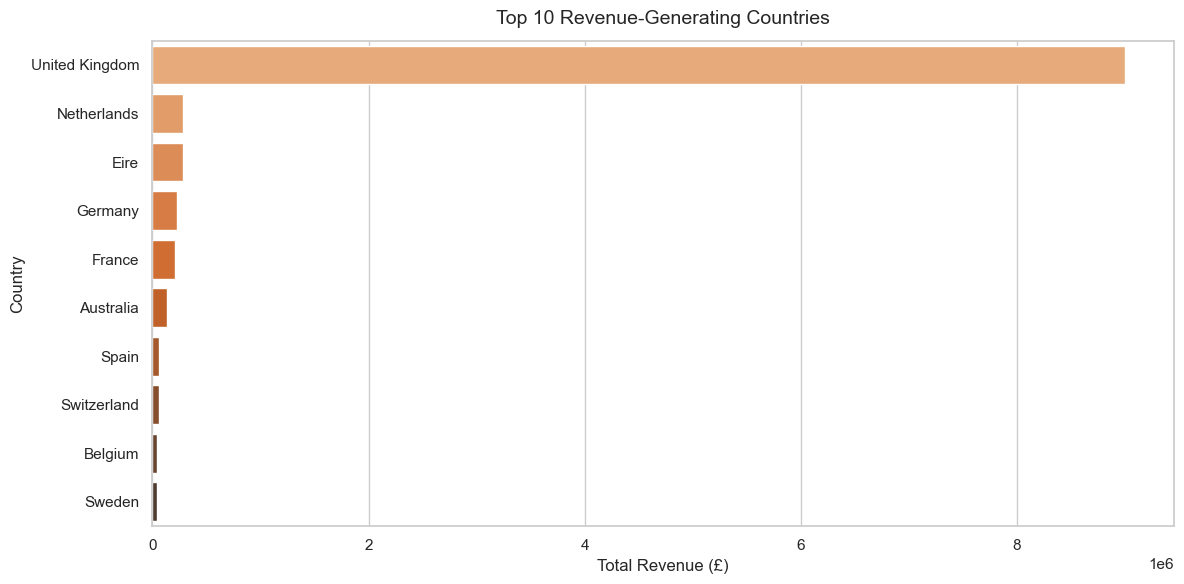

In [43]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=top_countries, x='revenue', y='country',
            palette='Oranges_d', ax=ax)
ax.set_title('Top 10 Revenue-Generating Countries', fontsize=14, pad=12)
ax.set_xlabel('Total Revenue (£)')
ax.set_ylabel('Country')
plt.tight_layout()
plt.savefig('ec_chart2_revenue_by_country.png', dpi=150)
plt.show()
# Finding: The United Kingdom dominates revenue, followed by Germany and France.

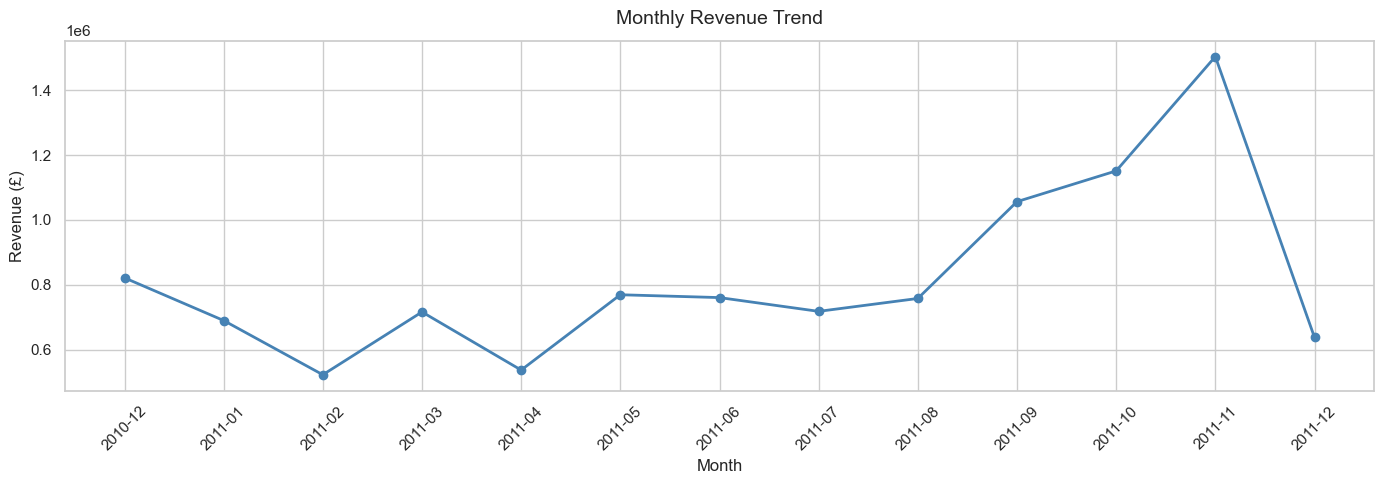

In [44]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_sales['year_month'], monthly_sales['revenue'],
        marker='o', color='steelblue', linewidth=2)
ax.set_title('Monthly Revenue Trend', fontsize=14, pad=12)
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('ec_chart3_monthly_trend.png', dpi=150)
plt.show()
# Finding: Revenue peaks in November, likely due to holiday shopping.

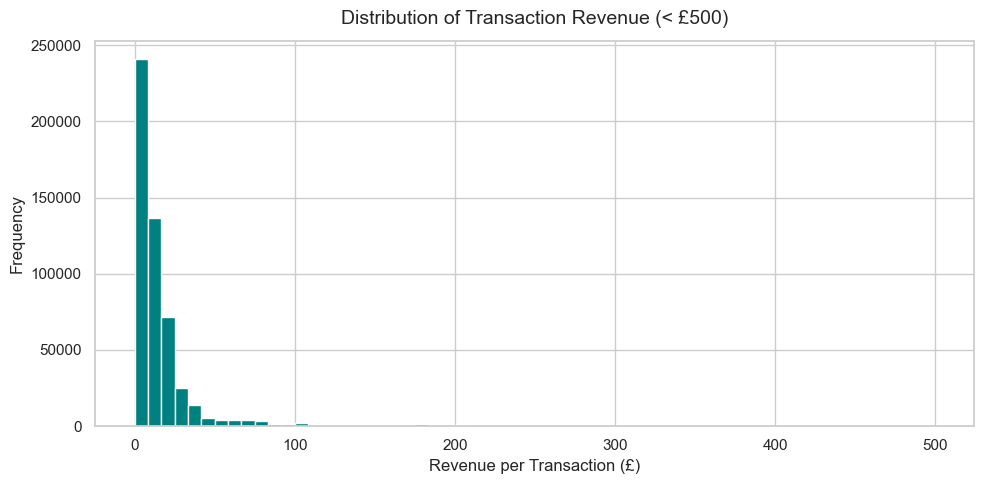

In [45]:
fig, ax = plt.subplots(figsize=(10, 5))
df_ec[df_ec['revenue'] < 500]['revenue'].hist(bins=60, color='teal',
                                               edgecolor='white', ax=ax)
ax.set_title('Distribution of Transaction Revenue (< £500)', fontsize=14, pad=12)
ax.set_xlabel('Revenue per Transaction (£)')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.savefig('ec_chart4_revenue_dist.png', dpi=150)
plt.show()
# Finding: Most transactions are low-value; distribution is right-skewed.

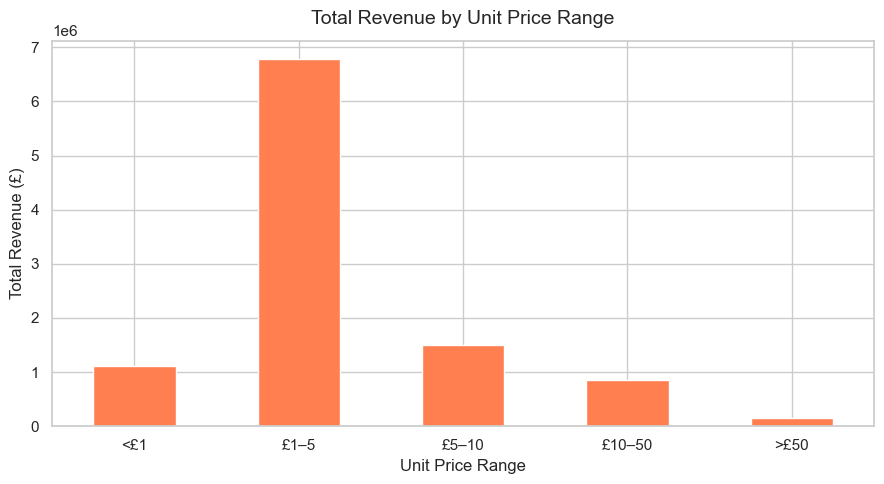

In [46]:
fig, ax = plt.subplots(figsize=(9, 5))
price_rev.plot(kind='bar', color='coral', edgecolor='white', ax=ax)
ax.set_title('Total Revenue by Unit Price Range', fontsize=14, pad=12)
ax.set_xlabel('Unit Price Range')
ax.set_ylabel('Total Revenue (£)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('ec_chart5_revenue_by_price.png', dpi=150)
plt.show()
# Finding: £1–5 price range contributes the most revenue overall.

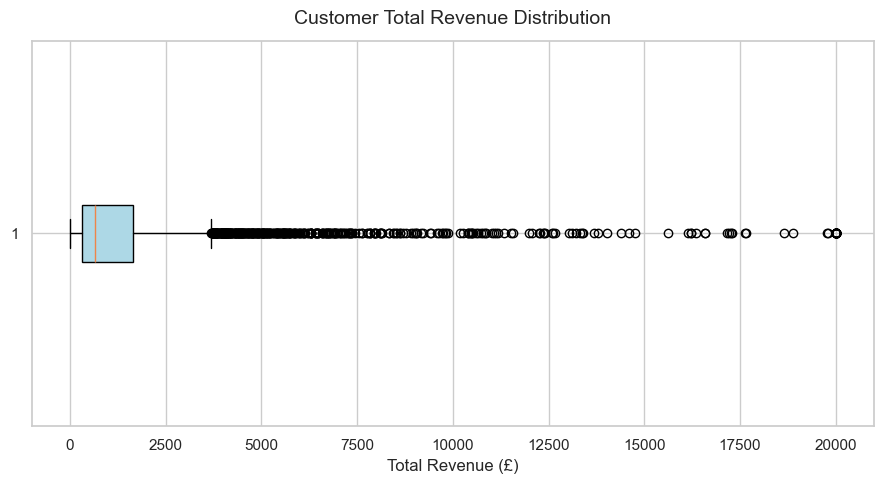

In [47]:
fig, ax = plt.subplots(figsize=(9, 5))
top_cust_data = customer_stats['total_revenue'].clip(upper=20000)
ax.boxplot(top_cust_data, vert=False, patch_artist=True,
           boxprops=dict(facecolor='lightblue'))
ax.set_title('Customer Total Revenue Distribution', fontsize=14, pad=12)
ax.set_xlabel('Total Revenue (£)')
plt.tight_layout()
plt.savefig('ec_chart6_customer_boxplot.png', dpi=150)
plt.show()
# Finding: Most customers spend moderately; a few high-value outliers skew the distribution.

### Task 5: Key Insights

The following insights are drawn from the cleaned data and supported by the visualizations above.

**Insight 1: The UK is the dominant market**
Over 85% of all revenue comes from the United Kingdom. While this is expected for a domestic retailer, it also represents a concentration risk. Germany, France, and the Netherlands are the next largest markets and present clear opportunities for targeted international growth. *(Supported by Chart 2)*

**Insight 2: Revenue is highly seasonal**
Sales peak sharply in November each year, driven by pre-Christmas and Black Friday shopping behaviour. The business should plan inventory, staffing, and marketing campaigns well in advance of Q4 to maximise this seasonal demand. *(Supported by Chart 3)*

**Insight 3: Low-priced products drive the most revenue**
Products priced between £1 and £5 generate the highest total revenue, confirming a high-volume, low-margin business model. Introducing product bundles or upselling strategies could help increase the average order value without changing the product range. *(Supported by Chart 5)*

**Insight 4: A small group of customers drives most revenue**
Analysis of customer purchasing behaviour shows that the top customers account for a disproportionately large share of total revenue — consistent with the Pareto principle. A loyalty or retention programme targeting these high-value customers would significantly reduce revenue risk. *(Supported by EDA — Customer Analysis)*

**Insight 5: Product demand is concentrated in a few items**
The top 10 products account for a significant share of all units sold. This means stockouts for these specific items would have an immediate and severe impact on revenue. Inventory management should prioritise these products above all others. *(Supported by Chart 1)*

In [50]:
df_ec.to_csv('ecommerce_cleaned.csv', index=False)
print("Saved: ecommerce_cleaned.csv")

Saved: ecommerce_cleaned.csv


In [51]:
print("=== FINAL SUMMARY ===")
print(f"E-commerce clean shape: {df_ec.shape}")
print("\nE-commerce columns:", df_ec.columns.tolist())

print("\nE-commerce sample:")
display(df_ec.head(3))



=== FINAL SUMMARY ===
E-commerce clean shape: (524878, 11)

E-commerce columns: ['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate', 'unitprice', 'customerid', 'country', 'revenue', 'year_month', 'price_range']

E-commerce sample:


,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,revenue,year_month,price_range
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.00,United Kingdom,15.30,2010-12,£1–5
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom,20.34,2010-12,£1–5
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.00,United Kingdom,22.00,2010-12,£1–5


## One-Page Summary Report

### Cleaning Challenges
- E-commerce: ~25% of CustomerIDs were missing (guest checkouts).
  Cancelled orders (InvoiceNo starting with 'C') needed manual removal.
  Encoding issues (ISO-8859-1) required a non-default file read.
- Netflix: Multiple missing fields (director, cast, country) with no
  reliable imputation method — filled with 'Not Available'/'Unknown'.
  date_added had inconsistent formatting and required parsing.

### Key EDA Findings
- E-commerce: UK dominates revenue; November is peak month; top 10%
  of customers drive most revenue; low-priced items drive volume.
- Netflix: Movies outnumber TV Shows ~2:1; content additions peaked
  2016–2019; US and India are top content producers; mature content
  (TV-MA) dominates; Drama and International genres lead.

### Top Insights
1. Both datasets show strong geographical concentration (UK for
   e-commerce; US/India for Netflix).
2. Time-based patterns are critical — both datasets show clear
   temporal trends worth monitoring.
3. Data quality issues (missing, inconsistent) were significant in
   both datasets, emphasising the importance of robust cleaning.
